In [2]:
# Importing the Libraries.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\abhis\\Downloads\\flights_data.csv")
print(df)

         index   airline   flight source_city departure_time stops  \
0            0  SpiceJet  SG-8709       Delhi        Evening  zero   
1            1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2            2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3            3   Vistara   UK-995       Delhi        Morning  zero   
4            4   Vistara   UK-963       Delhi        Morning  zero   
...        ...       ...      ...         ...            ...   ...   
300148  300148   Vistara   UK-822     Chennai        Morning   one   
300149  300149   Vistara   UK-826     Chennai      Afternoon   one   
300150  300150   Vistara   UK-832     Chennai  Early_Morning   one   
300151  300151   Vistara   UK-828     Chennai  Early_Morning   one   
300152  300152   Vistara   UK-822     Chennai        Morning   one   

         arrival_time destination_city     class  duration  days_left  price  
0               Night           Mumbai   Economy      2.17          1   5953  
1

In [ ]:
# Column Descriptions.

#1) index : Unique identifier for each row and it is just an index column, not useful for analysis.

#2) airline : Name of the airline operating the flight (e.g., Indigo, Air India, SpiceJet) and it is Categorical variable.

#3) flight : Flight code/number (e.g., AI-302, SG-122) and it identifies a specific flight within an airline.

#4) source_city : City from which the flight departs(e.g., Delhi, Chennai etc.) and it is a Categorical variable.

#5) departure_time  : Departure time category(like Morning, Afternoon, Evening, Night).

#6) stops : Number of stops between source and destination and 0 i.e. direct flights and one stop and two stops i.e connecting flights. Strongly influences flight price.

#7) arrival_time  :  Arrival time category (Morning, Afternoon, Evening, Night).

#8) destination_city :  City where the flight lands (e.g., Mumbai, Hyderabad etc.) and it is a Categorical variable.

#9) class :  Travel class of the ticket i.e. Economy, Business etc. Strong price determinant.

#10) duration :  Duration of the flight (in hours)and it is a Numeric variable (float). Longer flights typically cost more.

#11) days_left :  Number of days left before the journey date at the time of booking. Key factor in ticket price (closer dates i.e. usually higher price).

#12) price :  Ticket price in INR (Indian Rupees).

## EDA on this Dataset.

In [4]:
# Get the Quick Overview of the Dataset and Understand the structure of the Dataset.

print(df.shape)  # Rows and Columns of the Dataset.
print("Infornmation about the Dataset")
print(df.info()) # Complete Infornmation about the Columns of the Dataset.
print(df.columns) # Infornmation i.e. Names of the Columns about the Dataset.
print(df.head(5)) # Top 5 Rows of the Dataset.
print(df.tail(5)) # Last 5 Rows of the Dataset.
print(df.dtypes) # Getting Data - Types of each Column in the Dataset.
print(df.count())  # Count Non-Null Values in Each Column.

(300153, 12)
Infornmation about the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None
Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'de

               index       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751   20889.660523
std     86646.852011       7.191997      13.561004   22697.767366
min         0.000000       0.830000       1.000000    1105.000000
25%     75038.000000       6.830000      15.000000    4783.000000
50%    150076.000000      11.250000      26.000000    7425.000000
75%    225114.000000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000
                index  airline  flight source_city departure_time   stops  \
count   300153.000000   300153  300153      300153         300153  300153   
unique            NaN        6    1561           6              6       3   
top               NaN  Vistara  UK-706       Delhi        Morning     one   
freq              NaN   127859    3235       61343          71146  250863   
mean    150076.000000

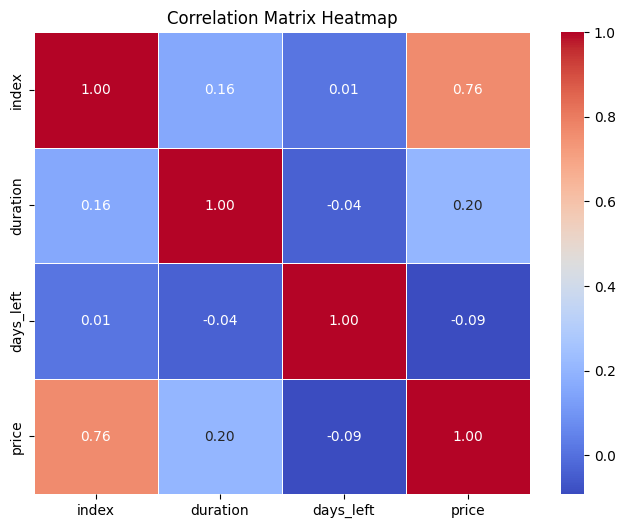

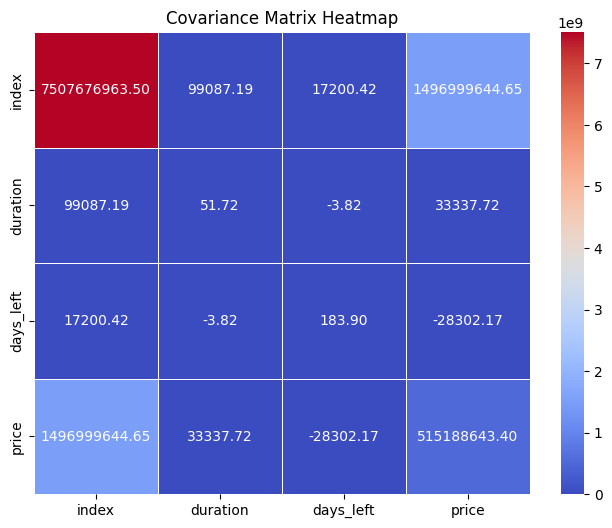

In [5]:
# Summary Statistics of the Dataset.

print(df.describe())  # Summary Statistics i.e. Mean, Min, Max etc. Values of all Numerical Columns in the Dataset.  
print(df.describe(include = 'all')) # Summary Statistics i.e. Mean, Min, Max etc. Values of all the Columns i.e. both Numerical and Categorical Columns in the Dataset.
print("Mean of days_left Column: ", df['days_left'].mean()) 
print("Median of days_left  Column: ", df['days_left'].median()) 
print("Mode of days_left Column: ", df['days_left'].mode())
print("Variance of days_left Column: ", df['days_left'].var())
print("Minimum Value of days_left Column: ", df['days_left'].min())
print("Maximum Value of days_left Column: ", df['days_left'].max())
print("Quantile Values of days_left Column: ", df['days_left'].quantile([0.25, 0.5, 0.75]))
print("Correlation with price :", df['days_left'].corr(df['price'])) # Correlation Matrix of days_left with the another column i.e. price. 
# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)
# Plot heatmap
# Correlation Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()
# Calculate Covariance Matrix.
covr_matrix = df.cov(numeric_only=True)
# Covariance Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(covr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Covariance Matrix Heatmap")
plt.show()




In [6]:
# Checking for the Missing Vaues i.e. find out the Missing Values.

print(df.isnull()) # Null - Values in the form of Boolean Matrix(True - Missing Values , False - Not a mssing Values).
print(df.notnull()) # Opposite of isnull(True - Not a Missing Values , False - Missing Values)
print(df.isnull().sum()) # Count of the Missing Values of each Columns.
# By illustration, it is clear there are no missing values in any column in the Dataset.

        index  airline  flight  source_city  departure_time  stops  \
0       False    False   False        False           False  False   
1       False    False   False        False           False  False   
2       False    False   False        False           False  False   
3       False    False   False        False           False  False   
4       False    False   False        False           False  False   
...       ...      ...     ...          ...             ...    ...   
300148  False    False   False        False           False  False   
300149  False    False   False        False           False  False   
300150  False    False   False        False           False  False   
300151  False    False   False        False           False  False   
300152  False    False   False        False           False  False   

        arrival_time  destination_city  class  duration  days_left  price  
0              False             False  False     False      False  False  
1      

In [7]:
# Handling Duplicates in the Dataset.

print(df.duplicated())  # Reurns a Boolean series i.e. True denotes Duplicate Value and False denotes Not a Duplicate Value.
print(df.duplicated().sum()) # Sum of the Duplicate Values.

# It is clear that there are no duplicate values in the Dataset.



0         False
1         False
2         False
3         False
4         False
          ...  
300148    False
300149    False
300150    False
300151    False
300152    False
Length: 300153, dtype: bool
0


In [8]:
# Count the Unique Values of the Dataset.

print(df.nunique()) # Unique Values of each Column of the Dataset.
print(df.nunique().sum())  # Get unique count for the entire DataFrame.
print(df['days_left'].nunique()) # Get unique count for a specific column.


index               300153
airline                  6
flight                1561
source_city              6
departure_time           6
stops                    3
arrival_time             6
destination_city         6
class                    2
duration               476
days_left               49
price                12157
dtype: int64
314431
49


0    1
1    1
2    1
3    1
4    1
Name: days_left, dtype: int64
300148    49
300149    49
300150    49
300151    49
300152    49
Name: days_left, dtype: int64
49
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49]
count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64
Median value of days_left 26.0
days_left
25    6633
18    6602
39    6593
32    6585
26    6573
24    6542
19    6537
31    6534
33    6532
40    6531
41    6525
28    6522
38    6512
20    6502
30    6501
42    6497
22    6494
36    6490
21    6479
37    6476
43    6472
44    6436
17    6419
11    6417
34    6412
13    6404
23    6401
29    6397
12    6381
27    6360
14    6349
15    6340
45    6314
35    6291
16    6272
46    6160
49    6154
48    6078
47    6069


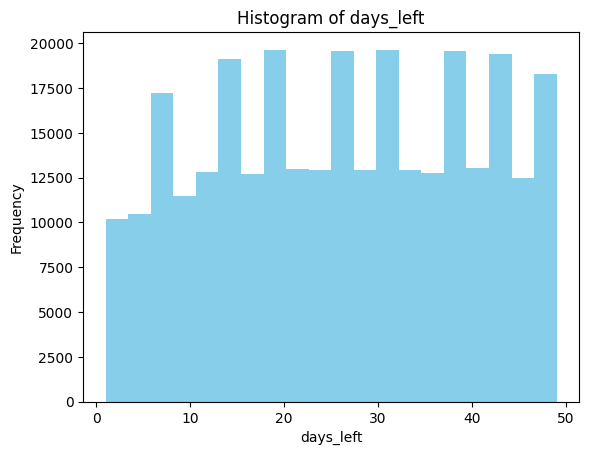

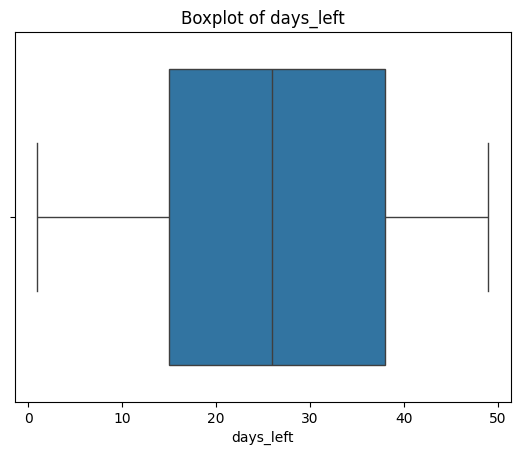

In [9]:
# Univariate Analysis.

print(df['days_left']. head(5)) # First Few values of the Particular Column.
print(df['days_left']. tail(5)) # Last Few values of the Particular Column.
print(df['days_left'].nunique()) # Get unique count for a specific column.
print(df['days_left'].unique()) # get unique values of a specific column.
print(df['days_left'].describe())
median_value = df['days_left'].median()
print("Median value of days_left", median_value)
print(df['days_left'].value_counts()) # Counts how many times each unique value appears in that column.
plt.hist(df['days_left'], bins=20, color='skyblue')
plt.xlabel('days_left')
plt.ylabel('Frequency')
plt.title('Histogram of days_left')
plt.show()

sns.boxplot(x=df['days_left'])
plt.title('Boxplot of days_left')
plt.show()


           days_left     price
days_left   1.000000 -0.091949
price      -0.091949  1.000000
            count          mean           std     min       25%      50%  \
days_left                                                                  
1          1927.0  21591.867151  19285.046391  4452.0  11524.50  15163.0   
2          4026.0  30211.299801  24420.921122  1977.0  12054.00  18017.5   
3          4248.0  28976.083569  24621.112460  3361.0  11255.00  16333.0   
4          5077.0  25730.905653  23120.423062  3362.0   9534.00  13054.0   
5          5392.0  26679.773368  24002.599834  3361.0   9281.50  13054.0   
6          5740.0  24856.493902  22200.882490  3361.0   9146.00  12417.5   
7          5703.0  25588.367351  22767.025911  3361.0   9201.00  12990.0   
8          5767.0  24895.883995  21711.801725  3361.0   9178.00  12658.0   
9          5665.0  25726.246072  21533.952229  3197.0   9879.00  13947.0   
10         5822.0  25572.819134  22194.098311  3197.0   9840.00  13303.

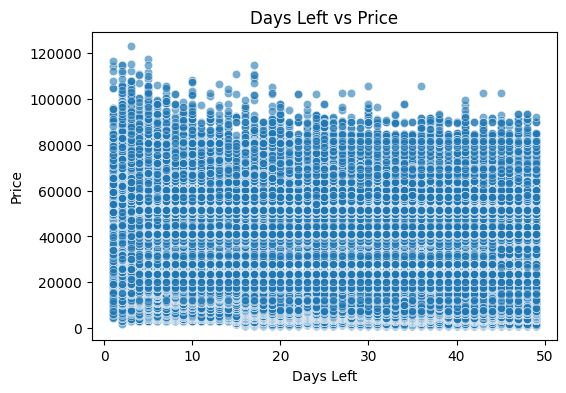

In [17]:
# Bivariate Analysis.

print(df[['days_left', 'price']].corr())  # Correlation between Two Variables.  
# +1 → Perfect positive correlation (as X ↑, Y ↑).
# -1 → Perfect negative correlation (as X ↑, Y ↓).
# 0 → No linear relationship.
print(df.groupby('days_left')['price'].describe()) # This gives mean, median, std deviation of price for each days_left group.
plt.figure(figsize=(6,4))
sns.scatterplot(x='days_left', y='price', data=df, alpha=0.6)
plt.title("Days Left vs Price")
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.show()


Lower Bound: -51824.0
Upper Bound: 99128.0
Original dataset size: (300153, 12)
Cleaned dataset size: (300030, 12)


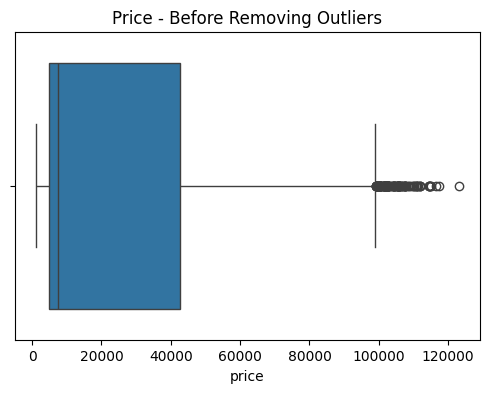

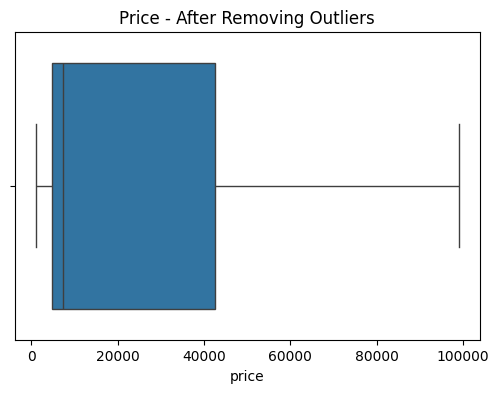

In [21]:
# Outliers Detection and Removing Outliers.

# Detect Outliers Using IQR.
Q1 = df['price'].quantile(0.25)  # 25th percentile
Q3 = df['price'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Any value below lower_bound or above upper_bound is considered an Outlier.

# Remove Outliers.

# Filter the dataset to remove Outliers.

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print("Original dataset size:", df.shape)
print("Cleaned dataset size:", df_clean.shape)

# df_clean → dataset without outliers in battery_power.

# You can now use df_clean for analysis or modeling.


import seaborn as sns
import matplotlib.pyplot as plt

# Before removing outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Price - Before Removing Outliers")
plt.show()

# After removing outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['price'])
plt.title("Price - After Removing Outliers")
plt.show()


# It is Clear from the Box - Plot , there are Outliers in price Column.


## Feature Engineering on this Dataset.

In [22]:
#) Scaling / Normalization.

#1) Scaling (or Normalization) is a way of resizing your numbers so that all your features (columns) are on a similar scale.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['price'] = scaler.fit_transform(df[['price']])
print(df['price'])

0         0.039749
1         0.039749
2         0.039773
3         0.039765
4         0.039765
            ...   
300148    0.558844
300149    0.623124
300150    0.639473
300151    0.659856
300152    0.659856
Name: price, Length: 300153, dtype: float64


In [23]:
# Binning / Discretization.

# Convert a Numerical Variable into Categories(bins). Useful for features like age, battery, price.

# Binning battery_power into 3 categories: Low, Medium, High.

df['price_bin'] = pd.cut(df['price'], bins=3, labels=['Low','Medium','High'])
print(df['price_bin'])

0            Low
1            Low
2            Low
3            Low
4            Low
           ...  
300148    Medium
300149    Medium
300150    Medium
300151    Medium
300152    Medium
Name: price_bin, Length: 300153, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']
